In [1]:
import pandas as pd

#running datafile 1 
df1 = pd.read_csv("/Users/seonamagdum/Downloads/Cardiovascular_Disease_Dataset.csv")
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patientid          1000 non-null   int64  
 1   age                1000 non-null   int64  
 2   gender             1000 non-null   int64  
 3   chestpain          1000 non-null   int64  
 4   restingBP          1000 non-null   int64  
 5   serumcholestrol    1000 non-null   int64  
 6   fastingbloodsugar  1000 non-null   int64  
 7   restingrelectro    1000 non-null   int64  
 8   maxheartrate       1000 non-null   int64  
 9   exerciseangia      1000 non-null   int64  
 10  oldpeak            1000 non-null   float64
 11  slope              1000 non-null   int64  
 12  noofmajorvessels   1000 non-null   int64  
 13  target             1000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 109.5 KB


In [2]:

!pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aasheesh200/framingham-heart-study-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/seonamagdum/.cache/kagglehub/datasets/aasheesh200/framingham-heart-study-dataset/versions/1


In [12]:
import pandas as pd

#running datafile 2
df2 = pd.read_csv("/Users/seonamagdum/.cache/kagglehub/datasets/aasheesh200/framingham-heart-study-dataset/versions/1/framingham.csv")

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path)

Path to dataset files: /Users/seonamagdum/.cache/kagglehub/datasets/fedesoriano/heart-failure-prediction/versions/1


In [13]:
import pandas as pd
import os

df3 = pd.read_csv("/Users/seonamagdum/.cache/kagglehub/datasets/fedesoriano/heart-failure-prediction/versions/1/heart.csv")


In [6]:

#making common columns 
common_columns = [
    "age",
    "sex",
    "cholesterol",
    "resting_bp",
    "max_hr",
    "target"
]

df1 = df1.rename(columns={
    "gender": "sex",
    "serumcholestrol": "cholesterol",
    "restingBP": "resting_bp",
    "maxheartrate": "max_hr",
    "target": "target"
})

#needed columns
df1 = df1[["age", "sex", "cholesterol", "resting_bp", "max_hr", "target"]]

df2 = df2.rename(columns={
    "male": "sex",
    "totChol": "cholesterol",
    "sysBP": "resting_bp",
    "heartRate": "max_hr",
    "TenYearCHD": "target"
})

#needed columns
df2 = df2[["age", "sex", "cholesterol", "resting_bp", "max_hr", "target"]]

df3 = df3.rename(columns={
    "Age": "age",
    "Sex": "sex",
    "Cholesterol": "cholesterol",
    "RestingBP": "resting_bp",
    "MaxHR": "max_hr",
    "HeartDisease": "target"
})

# convert to numeric
df3["sex"] = df3["sex"].map({"M": 1, "F": 0})

#needed columns
df3 = df3[["age", "sex", "cholesterol", "resting_bp", "max_hr", "target"]]

#drop missing values
df1 = df1.dropna()
df2 = df2.dropna()
df3 = df3.dropna()

df1["source"] = "cardio"
df2["source"] = "framingham"
df3["source"] = "heart"

combined_df = pd.concat([df1, df2, df3], ignore_index=True)


In [7]:
print(combined_df.head())
print(combined_df.info())

   age  sex  cholesterol  resting_bp  max_hr  target  source
0   53    1          0.0       171.0   147.0       1  cardio
1   40    1        229.0        94.0   115.0       0  cardio
2   49    1        142.0       133.0   202.0       0  cardio
3   43    1        295.0       138.0   153.0       1  cardio
4   31    1          0.0       199.0   136.0       1  cardio
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6107 entries, 0 to 6106
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          6107 non-null   int64  
 1   sex          6107 non-null   int64  
 2   cholesterol  6107 non-null   float64
 3   resting_bp   6107 non-null   float64
 4   max_hr       6107 non-null   float64
 5   target       6107 non-null   int64  
 6   source       6107 non-null   object 
dtypes: float64(3), int64(3), object(1)
memory usage: 334.1+ KB
None


In [8]:
# select key variables

cols = ["age", "cholesterol", "resting_bp", "max_hr"]
combined_df = combined_df[combined_df["cholesterol"] > 0]
# mean, min, max
print("Mean:\n", combined_df[cols].mean())
print("\nMin:\n", combined_df[cols].min())
print("\nMax:\n", combined_df[cols].max())

# full summary (includes quartiles)
print("\nFull Summary:\n", combined_df[cols].describe())

# IQR (Q3 - Q1)
iqr = combined_df[cols].quantile(0.75) - combined_df[cols].quantile(0.25)
print("\nIQR:\n", iqr)

Mean:
 age             49.935396
cholesterol    252.549643
resting_bp     135.424770
max_hr          95.149779
dtype: float64

Min:
 age            20.0
cholesterol    85.0
resting_bp     83.5
max_hr         44.0
dtype: float64

Max:
 age             80.0
cholesterol    696.0
resting_bp     295.0
max_hr         202.0
dtype: float64

Full Summary:
                age  cholesterol   resting_bp       max_hr
count  5882.000000  5882.000000  5882.000000  5882.000000
mean     49.935396   252.549643   135.424770    95.149779
std      10.787725    71.000741    23.992407    35.971221
min      20.000000    85.000000    83.500000    44.000000
25%      42.000000   209.000000   119.000000    70.000000
50%      50.000000   240.000000   130.000000    80.000000
75%      58.000000   277.000000   147.000000   110.000000
max      80.000000   696.000000   295.000000   202.000000

IQR:
 age            16.0
cholesterol    68.0
resting_bp     28.0
max_hr         40.0
dtype: float64


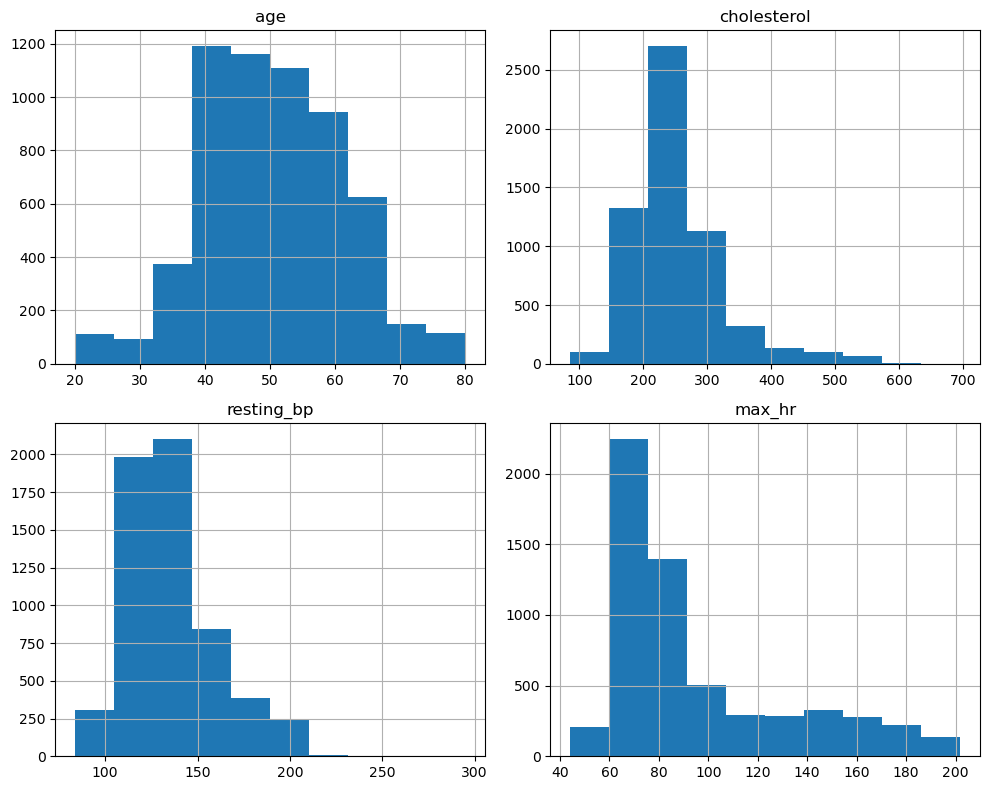

In [9]:
import matplotlib.pyplot as plt

combined_df[cols].hist(figsize=(10, 8)) 
plt.tight_layout()
plt.show()

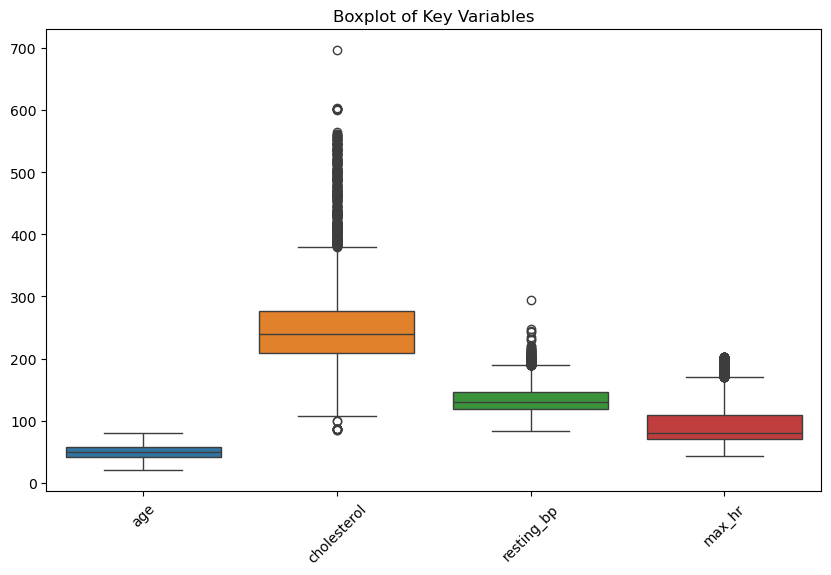

In [10]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=combined_df[cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Key Variables")
plt.show()

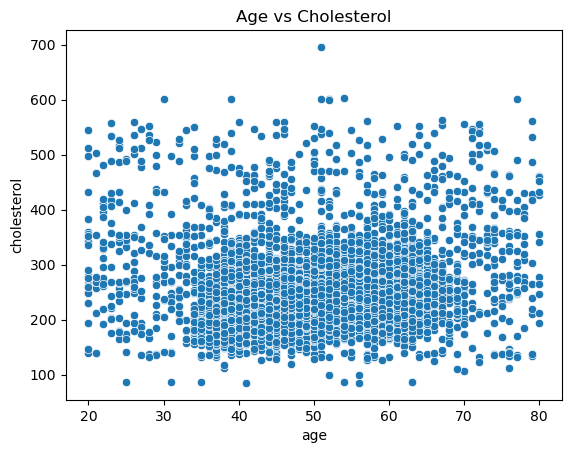

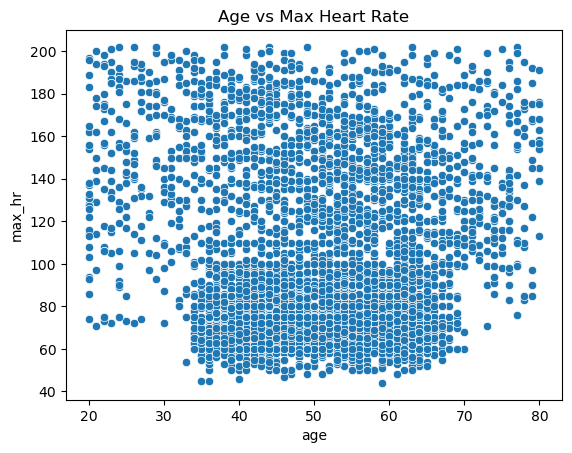

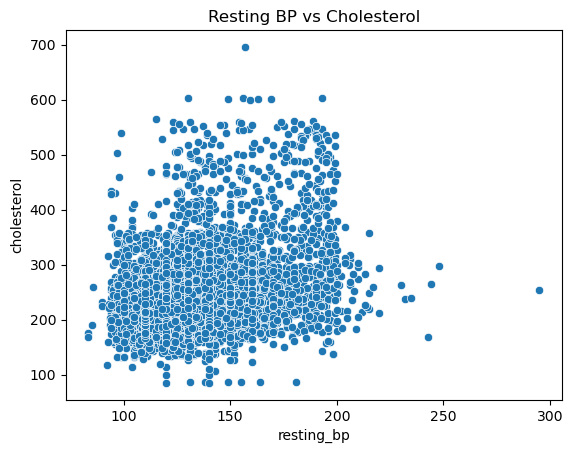

In [11]:
# Age vs Cholesterol
sns.scatterplot(x="age", y="cholesterol", data=combined_df)
plt.title("Age vs Cholesterol")
plt.show()

# Age vs Max Heart Rate
sns.scatterplot(x="age", y="max_hr", data=combined_df)
plt.title("Age vs Max Heart Rate")
plt.show()

# Resting BP vs Cholesterol
sns.scatterplot(x="resting_bp", y="cholesterol", data=combined_df)
plt.title("Resting BP vs Cholesterol")
plt.show()